# Ensamble analysis V1 pasive imaging 𓆝 𓆟 𓆞 𓆝 𓆟𓆝 𓆟 𓆞 𓆝 𓆟
---
This notebook shows the analysis pipeline for searching ensambles on two-photon calcium imaging data. This analysis is based on the results of analyses of individual neurons and pairs of neurons. These analyses revealed that BTBR exhibited reduced selectivity for orientation and direction, as well as greater noise correlation than the control group, raising questions regarding the level of population organization. This notebook assumes 2 experimental groups. 
The main question that guides this analysis is Can both the BTBR mice and C57B6 mice show ensamblatic activity on a pasive stimulation task? *Is equaly organized represented in both genotypes?*. 

## Imports and general setup

We first need to import the Python libraries we will use in the rest of the notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt   
from scipy import stats
from sklearn.covariance import LedoitWolf
from pathlib import Path

<div style="background-color:##99f720; border-left: 6px solid #99f720; padding: 10px; border-radius: 4px;">
    <h4 style="margin-top: 0;">What happens if a folder name isn't recognized?</h4>
    If a group folder is named something like BTBR_V1_copy it won't either match "BTBR" or "C57". When that happens `detect_genotype` raises an error instead of skipping the folder silently. Not doing it wouldn't break anything immediately, but that animal would silently drop out of the analysis (you might report N=12 when only 11 were actually processed, and nobody would notice until the sample sizes stop adding up.). The tradeoff is that if the pipeline stops, someone has to check it by hand. 
</div>

In [2]:
# ₊˚ʚ ROUTES ⠂⠁⠈⠂⠄⠄⠂⠁⠁⠂⠄⠄⠂⠁⠁⠂⠂⠁⠈⠂⠄⠄⠂⠁⠁⠂⠄⠄⠂⠁⠁⠂⠂⠁⠈⠂⠄⠄⠂⠁⠁⠂⠄⠄⠂⠁⠁⠂
DATA_ROOT = r'D:/AL-205/Nicole/Calcio/Nueva_carpeta'  # <── change this

# Keywords for detecting files (case-insensitive)
SCOPE_KEYWORD  = 'reg'     # TXT scope data
STIM_KEYWORD   = 'pas'     # TXT stimuli
TRACES_KEYWORD = 'traces'  # CSV calcium traces

# group folders → genotype
GENOTYPE_FOLDERS = {
    'BTBR': 'BTBR',
    'C57':  'C57',
}

# ₊˚ʚ  AQUISICION ⠂⠁⠈⠂⠄⠄⠂⠁⠁⠂⠄⠄⠂⠁⠁⠂⠂⠁⠈⠂⠄⠄⠂⠁⠁⠂⠄⠄⠂⠁⠁⠂⠂⠁⠈⠂⠄⠄⠂⠁⠁⠂⠄⠄⠂⠁⠁
SAMPLING_RATE = 5           # Hz
MS_PER_FRAME  = 1000 / SAMPLING_RATE  # 200 ms nominal — measured ~190ms in raw hardware counter, see Section 0. Pending resolution

# ₊˚ʚ  STIM WINDOWS ⠂⠁⠈⠂⠄⠄⠂⠁⠁⠂⠄⠄⠂⠁⠁⠂⠂⠁⠈⠂⠄⠄⠂⠁⠁⠂⠄⠄⠂⠁⠁⠂⠂⠁⠈⠂⠄⠄⠂⠁⠁⠂⠄⠄⠂⠁
SEC_BEFORE    = 2   # baseline window, matches stimulus protocol (see Methods)
SEC_AFTER     = 4   # stimulus window, matches trial duration
FRAMES_BEFORE = int(SEC_BEFORE * SAMPLING_RATE)   # 10
FRAMES_AFTER  = int(SEC_AFTER  * SAMPLING_RATE)   # 20
TOTAL_FRAMES  = FRAMES_BEFORE + FRAMES_AFTER       # 30

# Response window for used to compute per-angle mean response (tuning curve ➝ OSI/DSI)
RESP_START = FRAMES_BEFORE      # frame 10
RESP_END   = TOTAL_FRAMES       # frame 30

# ₊˚ʚ  THRESHOLD ⠂⠁⠈⠂⠄⠄⠂⠁⠁⠂⠄⠄⠂⠁⠁⠂⠂⠁⠈⠂⠄⠄⠂⠁⠁⠂⠄⠄⠂⠁⠁⠂⠂⠁⠈⠂⠄⠄⠂⠁⠁⠂⠄⠄⠂⠁
RESPONSIVE_STD   = 3    # STDs from baseline for a responsive neuron TODO: cite source
OSI_THRESH       = 0.7  # threshold for orientation-selective neuron, per TODO: cite source
SCE_ACTIVITY_STD = 1.5

# ₊˚ʚ  OUTPUT ⠂⠁⠈⠂⠄⠄⠂⠁⠁⠂⠄⠄⠂⠁⠁⠂⠂⠁⠈⠂⠄⠄⠂⠁⠁⠂⠄⠄⠂⠁⠁⠂⠂⠁⠈⠂⠄⠄⠂⠁⠁⠂⠄⠄⠂⠁⠁⠂
OUTPUT_DIR = Path(DATA_ROOT) / 'pipeline_output_ensambles'
OUTPUT_DIR.mkdir(exist_ok=True)

print('Setup ready')
print(f'Output → {OUTPUT_DIR}')

Setup ready
Output → D:\AL-205\Nicole\Calcio\Nueva_carpeta\pipeline_output_ensambles


In [3]:
# FUNTION MODULE
def find_file( folder: Path, keyword: str, preferred_extension: str = None) -> Path:
    """
    Searches within `folder` for a single file whose name contains `keyword`
    (case-insensitive).

    If there are multiple candidates and `preferred_extension` is specified, the results are filtered
    by that extension before a decision is made. If, after filtering, there are still
    more than one, or if `preferred_extension` is not specified and there is more than one candidate,
    an error is raised: the ambiguity must be resolved manually; the system never simply selects
    “the first one that appears.”
    """
    kw = keyword.lower()
    matches= [f for f in folder.iterdir() if f.is_file() and kw in f.name.lower()]

    if not matches:
        raise FileNotFoundError(f"Could'nt find any file with {keyword} in {folder}.")

    if preferred_extension and len(matches) > 1:
        filtered = [f for f in matches if f.suffix.lower() == preferred_extension.lower()]
        if filtered:
            matches = filtered

    if len(matches) > 1:
        names = [f.name for f in matches]
        raise ValueError(
            f"Ambiguity when searching for ‘{keyword}’ in {folder}: {len(matches)} candidates {names}. "
            "Resolve this manually before continuing"
        )
    return matches[0]

def detect_genotype(group_name: str) -> list:
    for kw, geno in GENOTYPE_FOLDERS.items():
        if kw.upper() in group_name.upper():
             raise ValueError(
                f"the genotype '{group_name}' in the folder can't be recognized."
                f"Known folders: {list(GENOTYPE_FOLDES.keys())}"
            )

def discover_animals (root: Path, genotype: str) -> list:
    """
    Discover all animals in the root folder for a given genotype.
    """
    root= Path (root)
    animals= []
    for group in sorted(root.iterdir()):
        if not group.is_dir() or group.name.startswith(".") or group.name== "pipeline_output":
            continue
        genotype = detect_genotype(group.name)
        for animal in sorted(group.iterdir()):
            if not animal.is_dir() or animal.name.startswith("."):
                continue
            animals.append({
                'Id': animal.name,
                'genotype': genotype,
                'group': group.name,
                'folder': animal,
            })
    if not animals:
        raise ValueError(f"No animals found in {root} for genotype {genotype}.")
    return animals

#Find files
def find_file(folder: Path, keyword: str) -> Path:
    """Finds the first file whose name contains keyword (case-insensitive).
    Excludes files that also contain other keywords, to avoid the
    traces CSV being detected as the stimulus TXT."""
    kw = keyword.lower()
    matches = [f for f in folder.iterdir()
               if f.is_file() and kw in f.name.lower()]
    if not matches:
        raise FileNotFoundError(
            f"No file found with '{keyword}' in {folder}")
    # If there are several, prefer TXT over CSV for log/stimulus keywords
    txt_matches = [f for f in matches if f.suffix.lower() == '.txt']
    csv_matches = [f for f in matches if f.suffix.lower() == '.csv']
    if kw in ['reg', 'pas']:
        return txt_matches[0] if txt_matches else matches[0]
    else:  # traces → prefer CSV
        return csv_matches[0] if csv_matches else matches[0]


def detect_genotype(group_name: str) -> str:
    for kw, geno in GENOTYPE_FOLDERS.items():
        if kw.upper() in group_name.upper():
            return geno
    return 'Unknown'


def discover_subjects(root: str) -> list:
    """Walks two levels: group/subject."""
    root = Path(root)
    subjects = []
    for group in sorted(root.iterdir()):
        if not group.is_dir() or group.name.startswith('.') \
                or group.name == 'pipeline_output':
            continue
        genotype = detect_genotype(group.name)
        for subject in sorted(group.iterdir()):
            if not subject.is_dir() or subject.name.startswith('.'):
                continue
            subjects.append({
                'subject_id': subject.name,
                'genotype':   genotype,
                'group':      group.name,
                'folder':     subject,
            })
    return subjects

##read scope and stimuli

def parse_scope_txt(filepath: Path) -> tuple:
    """Parses the microscope TXT file.
    Format: HH:MM:SS.microsec.frameN.flag.channel
    Returns timestamp_strs, millisec (normalized to t=0), sensors."""
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
    datasplit = [l.strip().split('.') for l in lines[1:]]
    datasplit = [d for d in datasplit if len(d) >= 4]
    timestamp_strs = [d[0] for d in datasplit]
    millisec  = np.array([float(d[2]) for d in datasplit])
    sensors   = np.array([float(d[3]) for d in datasplit])
    millisec  = millisec - millisec[0]
    return timestamp_strs, millisec, sensors


def parse_stim_txt(filepath: Path) -> tuple:
    """Parses the stimulus TXT file.
    Format: HH:MM:SS.mmm.FLAG
      11   → stimulus onset
      0XXX → angle when it ends (4s later)
    Returns tstamp_stlog, stimuli."""
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
    datasplit    = [l.strip().split('.') for l in lines]
    datasplit    = [d for d in datasplit if len(d) >= 3]
    tstamp_stlog = [d[0] for d in datasplit]
    stimuli      = np.array([float(d[2]) for d in datasplit])
    return tstamp_stlog, stimuli


def get_clean_frame_times(millisec: np.ndarray, sensors: np.ndarray,
                           min_interval_ms: float = 100.0) -> np.ndarray:
    """Extracts real frame times (flag==23), removing duplicates."""
    framt    = np.where(sensors == 23)[0]
    t_fram   = millisec[framt]
    ll       = np.diff(t_fram)
    idx_keep = np.where(ll > min_interval_ms)[0] + 1
    return np.insert(t_fram[idx_keep], 0, t_fram[0])

## align stims and frames

def align_stimuli_to_frames(timestamp_strs, millisec, sensors,
                             tstamp_stlog, stimuli,
                             ms_per_frame: float = 200.0) -> np.ndarray:
    """Returns stimsnframes (n_angles, n_trials, 2):
       [:,:,0] = angle, [:,:,1] = onset frame.

    Note: n_trials is derived from angle counts only. The onset flag (11)
    is unreliable — it can register spuriously during acquisition — so its
    count is not used to determine trial number."""
    t_fram_clean = get_clean_frame_times(millisec, sensors)
    max_frame    = len(t_fram_clean) - 1

    stims_all, stim_counts = np.unique(stimuli, return_counts=True)
    stims    = stims_all[stims_all != 11]
    n_trials = int(np.min(stim_counts[stims_all != 11]))

    idx_t_stim = np.zeros((n_trials, len(stims)))

    ts_arr = np.array(timestamp_strs)
    for s, stim in enumerate(stims):
        t_stamp_idx = np.where(stimuli == stim)[0]
        t_stamp     = [tstamp_stlog[i - 1] for i in t_stamp_idx]
        for j, ts in enumerate(t_stamp):
            if j >= n_trials:
                break
            hms = list(map(int, ts.split(':')))
            hms[2] += 1
            ts2 = f"{hms[0]:02}:{hms[1]:02}:{hms[2]:02}"
            idx_bin = np.concatenate((
                np.where(ts_arr == ts)[0],
                np.where(ts_arr == ts2)[0]
            ))
            if len(idx_bin) > 0:
                idx_stim_j = np.where(
                    sensors[idx_bin[0]:idx_bin[-1]] == 4
                )[0] + idx_bin[0]
                if len(idx_stim_j) > 0:
                    idx_t_stim[j, s] = idx_stim_j[0]

    t_Stim_ms   = millisec[idx_t_stim.astype(int)]
    tf          = np.round(t_Stim_ms / ms_per_frame).astype(int)
    tf_clamped  = np.clip(tf, 0, max_frame)
    late        = t_Stim_ms - t_fram_clean[tf_clamped] > ms_per_frame
    tf[late]   += 1
    tf          = np.clip(tf, 0, max_frame).T  # (n_angles, n_trials)

    stims_tiled  = np.tile(stims[:, np.newaxis], (1, tf.shape[1]))
    stimsnframes = np.stack([stims_tiled, tf], axis=2)
    return stimsnframes

## extract responsive neurons

def extract_aligned_signals(traces_csv: Path, stimsnframes: np.ndarray,
                             frames_before: int = FRAMES_BEFORE,
                             frames_after:  int = FRAMES_AFTER) -> dict:
    """Returns extracted_data: {angle: array(N_neurons, T_frames, N_trials)}.
    Normalization: dF/F0 with baseline = pre-stimulus window."""
    # Handle separator and decimal format for files exported in Spanish locale
    df = load_traces_csv(traces_csv)

    extracted_data = {}
    n_frames_total = len(df)
    total = frames_before + frames_after
    F_global_median = np.median(df.values, axis=0)

    for ai in range(stimsnframes.shape[0]):
        for ti in range(stimsnframes.shape[1]):
            angle = int(stimsnframes[ai, ti, 0])
            sf    = int(stimsnframes[ai, ti, 1])
            start = sf - frames_before
            end   = sf + frames_after

            if start >= 0 and end <= n_frames_total:
                F = df.iloc[start:end].values
            else:
                # Pad with global median
                F = np.zeros((total, df.shape[1]))
                s_clip = max(0, start)
                e_clip = min(n_frames_total, end)
                src    = df.iloc[s_clip:e_clip].values
                dst_s  = s_clip - start
                F[:, :]        = F_global_median
                F[dst_s:dst_s + len(src), :] = src

            F0     = np.median(F[:frames_before], axis=0)
            signal = (F - F0) / (F0 + 1e-10)

            extracted_data.setdefault(angle, []).append(signal)

    for angle in extracted_data:
        stacked = np.stack(extracted_data[angle], axis=-1)   # (T, N, trials)
        extracted_data[angle] = np.transpose(stacked, (1, 0, 2))  # (N, T, trials)

    return extracted_data

def load_traces_csv(traces_csv: Path) -> pd.DataFrame:
    """Loads the CaImAn traces CSV, handling locale decimal format and dropping a posible index/time column. 
    Return the full , unclipped trace: rows = frames, columns = neurons.
    """
    df= pd.read_csv(traces_csv, decimal= ',', sep= None, engine= 'python')
    if df.columns[0].lower() in ['unnamed:0','index', 'time', 'frame']:
        df.drop(df.columns[0], axis=1, inplace=True)
    df= df.apply(pd.to_numeric, errors='coerce').fillna(0)
    return df
    

def find_responsive_neurons(extracted_data: dict,
                             threshold_std: float = RESPONSIVE_STD) -> list:
    """A neuron is responsive if its mean response to any angle
    exceeds threshold_std * std(baseline)."""
    n_neurons = next(iter(extracted_data.values())).shape[0]
    responsive = []
    for n in range(n_neurons):
        for angle, data in extracted_data.items():
            d         = data[n]             # (T, trials)
            threshold = np.std(d[:FRAMES_BEFORE]) * threshold_std
            response  = np.mean(d[RESP_START:RESP_END])
            if response > threshold:
                responsive.append(n)
                break
    return responsive

def load_continuous_traces(traces_csv: Path) -> tuple[np.ndarray, int]:
    """ Returns the uncropped record for a subject: 
    (traces, n_frames_total)
    - traces: array (N_neurons , T_frames_total)
    - n_frames_total: T, to verify the T/N ratio before applying PCA + ICA
    """
    df = load_traces_csv(traces_csv)
    traces = df.to_numpy().T  # (N_neurons, T_frames_total)
    n_frames_total = df.shape[0]
    return traces, n_frames_total

#Final dataset

def build_population_dataset_nc(subject_data: dict) -> dict:
    """Version for noise correlations. Preserves per-subject structure —
    correlations are only meaningful within a subject, where pairs of
    neurons share the exact same trials. No cross-subject concatenation
    or trial truncation."""
    pop_data = {}
    genotypes = set(d['genotype'] for d in subject_data.values())

    for geno in genotypes:
        subjects_geno = {sid: d for sid, d in subject_data.items()
                        if d['genotype'] == geno}

        all_angle_sets = [set(d['extracted_data'].keys())
                          for d in subjects_geno.values()]
        common_angles  = sorted(set.intersection(*all_angle_sets))

        resp_by_subject_angle = {}
        for sid, data in subjects_geno.items():
            ext  = data['extracted_data']
            resp = data['responsive']
            resp_by_subject_angle[sid] = {
                angle: ext[angle][resp, RESP_START:RESP_END, :]  # (N_i, T_resp, trials_i)
                for angle in common_angles
            }

        pop_data[geno] = {
            'angles':                common_angles,
            'subject_ids':           list(subjects_geno.keys()),
            'resp_by_subject_angle': resp_by_subject_angle,
        }

    return pop_data

In [4]:
subjects = discover_subjects(DATA_ROOT)
print(f'Subjects found: {len(subjects)}')
for s in subjects:
    print(f"  [{s['genotype']:6}]  {s['group']}/{s['subject_id']}")

Subjects found: 11
  [BTBR  ]  BTBR/BTBR_R2_060725
  [BTBR  ]  BTBR/BTBR_R2_270923_hembra_pasiva_Isaac
  [BTBR  ]  BTBR/BTBRL1030825_Reg_12_12_25
  [BTBR  ]  BTBR/BTBRR1_280825_Reg_15_12_25
  [C57   ]  C57/C57_SM_Isaac
  [C57   ]  C57/C57L10300325_pasiva
  [C57   ]  C57/C57L2_Isaac
  [C57   ]  C57/C57R1230825_Reg_15_12_25
  [C57   ]  C57/C57R20010525_pasiva
  [C57   ]  C57/C57R3230825_Reg_15_12_25
  [C57   ]  C57/Delta 4-22 wt


In [5]:
all_results  = []
subject_data = {}
failed       = []

for subject in subjects:
    sid    = subject['subject_id']
    folder = subject['folder']
    geno   = subject['genotype']
    sep    = '=' * 60
    print(f'\n{sep}')
    print(f'  Processing: {sid}  [{geno}]')
    print(sep)
    try:
        scope_file  = find_file(folder, SCOPE_KEYWORD)
        stim_file   = find_file(folder, STIM_KEYWORD)
        traces_file = find_file(folder, TRACES_KEYWORD)
        print(f'  scope  : {scope_file.name}')
        print(f'  stim   : {stim_file.name}')
        print(f'  traces : {traces_file.name}')

        ts_strs, millisec, sensors = parse_scope_txt(scope_file)
        tstamp_stlog, stimuli      = parse_stim_txt(stim_file)
        flags, counts = np.unique(sensors, return_counts=True)
        print(f'  Scope flags : {dict(zip(flags.astype(int), counts))}')
        print(f'  Stim flags  : {dict(zip(*np.unique(stimuli, return_counts=True)))}')

        t_clean = get_clean_frame_times(millisec, sensors)
        print(f'  Clean frames: {len(t_clean)}')

        stimsnframes = align_stimuli_to_frames(
            ts_strs, millisec, sensors,
            tstamp_stlog, stimuli,
            ms_per_frame=MS_PER_FRAME
        )
        print(f'  stimsnframes: {stimsnframes.shape}  '
              f'(angles={stimsnframes.shape[0]}, trials={stimsnframes.shape[1]})')

        extracted_data = extract_aligned_signals(traces_file, stimsnframes)
        sample_angle   = next(iter(extracted_data))
        n_neurons      = extracted_data[sample_angle].shape[0]
        print(f'  Angles: {sorted(extracted_data.keys())}')
        print(f'  Shape per angle: {extracted_data[sample_angle].shape}  '
              f'(neurons, frames, trials)')

        responsive = find_responsive_neurons(extracted_data)
        print(f'  Responsive: {len(responsive)} / {n_neurons} '
              f'({100*len(responsive)/n_neurons:.1f}%)')

        subject_data[sid] = {
            'extracted_data': extracted_data,
            'responsive':     responsive,
            'genotype':       geno,
            'traces_file':      traces_file,
            'stimsnframes': stimsnframes,
        }
        all_results.append(sid)

    except Exception:
        print(f'  ERROR in {sid}:')
        traceback.print_exc()
        failed.append(sid)

sep = '=' * 60
print(f'\n{sep}')
print(f'Successful: {len(all_results)} / {len(subjects)}')
if failed:
    print(f'Failed: {failed}')


  Processing: BTBR_R2_060725  [BTBR]
  scope  : BTBRmachor2060725_reg112539.txt
  stim   : BTBRmachor2060725_pas112548.txt
  traces : machoR2_060725_BTBR_pasiva_OryDir_CTraces.csv
  Scope flags : {np.int64(2): np.int64(998), np.int64(4): np.int64(309), np.int64(5): np.int64(329), np.int64(23): np.int64(36803)}
  Stim flags  : {np.float64(0.0): np.int64(10), np.float64(11.0): np.int64(90), np.float64(45.0): np.int64(10), np.float64(90.0): np.int64(10), np.float64(135.0): np.int64(10), np.float64(180.0): np.int64(10), np.float64(225.0): np.int64(10), np.float64(270.0): np.int64(10), np.float64(315.0): np.int64(10)}
  Clean frames: 6071
  stimsnframes: (8, 10, 2)  (angles=8, trials=10)
  Angles: [0, 45, 90, 135, 180, 225, 270, 315]
  Shape per angle: (187, 30, 10)  (neurons, frames, trials)
  Responsive: 183 / 187 (97.9%)

  Processing: BTBR_R2_270923_hembra_pasiva_Isaac  [BTBR]
  scope  : BTBR_hembra_R2_día2_144142reg.txt
  stim   : BTBR_R2_hembra_dia2_PASIVA_pas.txt
  traces : BTBR_HEM

In [6]:
# Population dataset
pop_data = build_population_dataset_nc(subject_data)

for geno, pdata in pop_data.items():
    sample_angle = pdata['angles'][0]
    subject_ids  = pdata['subject_ids']

    n_neurons_per_subject = {
        sid: pdata['resp_by_subject_angle'][sid][sample_angle].shape[0]
        for sid in subject_ids
    }
    total_neurons = sum(n_neurons_per_subject.values())

    print(f'\n{geno}: {total_neurons} total responsive neurons across '
          f'{len(subject_ids)} subjects')
    print(f'  Angles: {pdata["angles"]}')
    print(f'  Neurons per subject: {n_neurons_per_subject}')
    print(f'  Subjects included: {subject_ids}')


C57: 851 total responsive neurons across 7 subjects
  Angles: [0, 45, 90, 135, 180, 225, 270, 315]
  Neurons per subject: {'C57_SM_Isaac': 65, 'C57L10300325_pasiva': 72, 'C57L2_Isaac': 56, 'C57R1230825_Reg_15_12_25': 125, 'C57R20010525_pasiva': 142, 'C57R3230825_Reg_15_12_25': 164, 'Delta 4-22 wt': 227}
  Subjects included: ['C57_SM_Isaac', 'C57L10300325_pasiva', 'C57L2_Isaac', 'C57R1230825_Reg_15_12_25', 'C57R20010525_pasiva', 'C57R3230825_Reg_15_12_25', 'Delta 4-22 wt']

BTBR: 442 total responsive neurons across 4 subjects
  Angles: [0, 45, 90, 135, 180, 225, 270, 315]
  Neurons per subject: {'BTBR_R2_060725': 183, 'BTBR_R2_270923_hembra_pasiva_Isaac': 93, 'BTBRL1030825_Reg_12_12_25': 44, 'BTBRR1_280825_Reg_15_12_25': 122}
  Subjects included: ['BTBR_R2_060725', 'BTBR_R2_270923_hembra_pasiva_Isaac', 'BTBRL1030825_Reg_12_12_25', 'BTBRR1_280825_Reg_15_12_25']


Subjects with less than 20 responsive neurons are excluded

## Detection of Population Synchrony Events (SCE)<sup id="fnref1"><a href="#fn1">1</a></sup>

**Are there moments in the recordings (whether evoked or spontaneous) when neurons fire toghether more frequently than chance would predict?**

1. Binarize the activity of each neuron (active/inactive per frame). Here we use a lower threshold (1.5 SD) in accordance with standard practice in the literature on the detection of synchronous events, where the goal is to capture minimal coincident activation among neurons, not the magnitude of an individual response.
2. Count, in each frame, how many neurons are active simultaneuosly.
3. Generate a null distribution by circularly shifting the trace of each  neuron independently (to preserve the activity rate of each neuron but destroys any real temporal relationship between them).
4. Compare the observed coactivityagainst this null distribution:
    -Frames whose coactivity exceeds the 95th-99th percentile of what would be expected by chance are marked as Synchonious Events (SCE).

**Since We've alredy saw a higher rate of spontaneous events at the single neuron level, we expect more spontaneous SCEs in the BTBR mice.
 Also we expect evoked SCEs to be less aligned with the stimulus in BTBR**
<p id="fn1"> 1- Xue, F., Li, F., Zhang, K. M., Ding, L., Wang, Y., Zhao, X., Xu, F., Zhang, D., Sun, M., Lau, P. M., Zhu, Q., Zhou, P., & Bi, G. Q. (2023). Multi-region calcium imaging in freely behaving mice with ultra-compact head-mounted fluorescence microscopes. National science review, 11(1), nwad294. https://doi.org/10.1093/nsr/nwad294 </p>

In [7]:
traces, n_frames = load_continuous_traces(traces_file)
print(f'{sid}: traces shape = {traces.shape}, n_frames_total = {n_frames}')

Delta 4-22 wt: traces shape = (257, 4306), n_frames_total = 4306


In [8]:
continuous_traces_data={}
failed_continuous= []

for sid, data in subject_data.items():
    print(f"Processing continuous traces: {sid}")
    try:
        traces_file= data ['traces_file']
        traces, n_frames_total = load_continuous_traces(traces_file)

        continuous_traces_data[sid]= {
            'traces': traces,
            'n_frames_total': n_frames_total,
            'genotype': data['genotype']
        }
        print(f'shape= {traces.shape}, n_frames_total= {n_frames_total}.')

    except Exception:
        print(f'ERROR in {sid}:')
        traceback.print_exc()
        failed_continuous.append(sid)

print(f'\nSuccessful:{len(continuous_traces_data)}/{len(subject_data)}')
if failed_continuous:
    print(f'Failed: {failed_continuous}')

Processing continuous traces: BTBR_R2_060725
shape= (187, 6103), n_frames_total= 6103.
Processing continuous traces: BTBR_R2_270923_hembra_pasiva_Isaac
shape= (93, 4449), n_frames_total= 4449.
Processing continuous traces: BTBRL1030825_Reg_12_12_25
shape= (92, 3021), n_frames_total= 3021.
Processing continuous traces: BTBRR1_280825_Reg_15_12_25
shape= (127, 5500), n_frames_total= 5500.
Processing continuous traces: C57_SM_Isaac
shape= (66, 4350), n_frames_total= 4350.
Processing continuous traces: C57L10300325_pasiva
shape= (78, 4564), n_frames_total= 4564.
Processing continuous traces: C57L2_Isaac
shape= (57, 4350), n_frames_total= 4350.
Processing continuous traces: C57R1230825_Reg_15_12_25
shape= (140, 5466), n_frames_total= 5466.
Processing continuous traces: C57R20010525_pasiva
shape= (146, 5240), n_frames_total= 5240.
Processing continuous traces: C57R3230825_Reg_15_12_25
shape= (168, 5409), n_frames_total= 5409.
Processing continuous traces: Delta 4-22 wt
shape= (257, 4306), n_f

### 1. Binarize Traces

In [9]:
def binzarize_traces(traces:np.ndarray, threshold: float = SCE_ACTIVITY_STD) -> np.ndarray:
    """ 
    Binarize the activity of each neuron along time.

    traces: array (N_neurons, T_frames), the continuous trace.
    threhold_std: 
    """
    mean_per_neuron= np.mean(traces, axis=1, keepdims=True) #(N,1)
    std_per_neuron= np.std(traces, axis=1, keepdims= True) #(N,1)

    flat_neurons = (std_per_neuron.flatten()==0)
    if flat_neurons.any():
        print(f'Warning: {flat_neurons.sum()} neuron(s) with std= 0 excluded from calculus')

    
    
    valid= ~flat_neurons
    z_scores= np.zeros_like(traces)
    z_scores[valid] = (traces[valid] - mean_per_neuron[valid]) / std_per_neuron [valid]

    binary = (z_scores > threshold).astype(int)
    return binary

In [10]:
traces_tests= continuous_traces_data['Delta 4-22 wt']['traces']
binary_test= binzarize_traces(traces_tests)
print(binary_test.shape)
print(f"fraction of active frames (average across neurons):{binary_test.mean():.3f}")

(257, 4306)
fraction of active frames (average across neurons):0.082


In [11]:
active_fraction_per_neuron= binary_test.mean(axis=1) # (N,)
print(f"Min: {active_fraction_per_neuron.min():.3f}, Max: {active_fraction_per_neuron.max():.3f}")

Min: 0.025, Max: 0.127


tested the threshold, looks fine.

### 2. Count Coactivity per Frame

In [12]:
def count_coactivity(binary_traces: np.ndarray) -> np.ndarray:
    """ 
    Counts how many neurons are active simultaneously in each frame.

    binary_traces: array (N_neurons, T_frames), binary (0/1)

    Returns: array (T_frames,) — number of active neurons per frame
    """

    coactivity= np.sum(binary_traces, axis=0) #(T,)
    return coactivity

(4306,)
Máxima coactividad observada: 66 neuronas


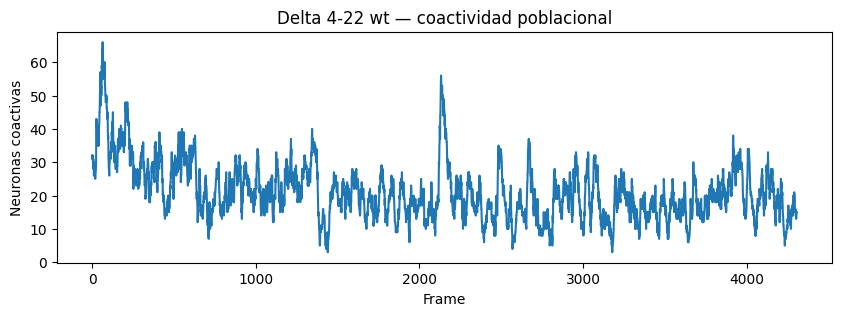

In [13]:
coactivity_test = count_coactivity(binary_test)
print(coactivity_test.shape)  # debería ser (4306,) para este sujeto
print(f'Máxima coactividad observada: {coactivity_test.max()} neuronas')

plt.figure(figsize=(10, 3))
plt.plot(coactivity_test)
plt.xlabel('Frame')
plt.ylabel('Neuronas coactivas')
plt.title('Delta 4-22 wt — coactividad poblacional')
plt.show()

When plotting `coactivity` (the number of active neurons per frame), I was surprised to find that
the signal visually resembled an LFP (local field potential) recording
 (with continuous fluctuations rather than isolated, clean spikes on a flat
baseline).

This makes sense and is not an error: both the LFP and this signal are
**aggregate measures of population activity over time**. The LFP sums the electrical
currents of many nearby neurons; `coactivity` sums how many neurons are
active (according to our binary threshold) at each instant. Both inherit the same
type of background fluctuation because they aggregate many sources, each with its own
variability.

This is important because it means that **I cannot rely on identifying
“synchrony events” simply by looking at the peaks with the naked eye**—any
sum of many variables with noise will produce fluctuations that appear to be
“events” even if there is no actual synchrony among neurons. The next step
(comparing against a distribution generated by shuffles) is what allows us to
distinguish genuine synchrony from what is expected by chance alone when summing 257
independent neurons.

### 3.Circular Shift

In [14]:
def circular_shift_traces(binary_traces: np.ndarray, rng:np.random.Generator) -> np.ndarray:
    """
    Generates a “shuffled” version of the binary raster by rotating each neuron
    (each row) independently and with a different random offset.
    It preserves the firing rate of each neuron but destroys the temporal
    relationship between neurons.

    binary_traces: array (N_neurons, T_frames)
    rng: random number generator (for reproducibility)

    Returns: array (N_neurons, T_frames), same size, rotated row by row
    """
    n_neurons, n_frames = binary_traces.shape
    shifted= np.zeros_like(binary_traces)

    for i in range (n_neurons):
        shift_amount = rng.integers (0, n_frames)
        shifted[i] =np.roll(binary_traces[i], shift_amount)

    return shifted

def build_null_distribution(binary_traces: np.ndarray,
                                n_shuffles: int = 1000,
                                seed: int=0) -> np.ndarray:
    """ 
    Constructs the null distribution of the maximum coactivity peak,
    by repeating the circular shift n_shuffles times.

    binary_traces: array (N_neurons, T_frames)
    n_shuffles: number of shuffle repetitions
    seed: seed for reproducibility

    Returns: array (n_shuffles,) — the maximum coactivity for each repetition
    """
    rng=np.random.default_rng(seed)
    null_maxima= np.zeros(n_shuffles)

    for s in range (n_shuffles):
        shifted=circular_shift_traces(binary_traces, rng)
        coactivity_shifted= count_coactivity(shifted)
        null_maxima[s] = coactivity_shifted.max()

    return null_maxima

In [15]:
null_dist = build_null_distribution(binary_test, n_shuffles=1000)
print (f"Null distribution: mean= {null_dist.mean():.1f}, std= {null_dist.std():.1f}")
print(f"99th percentile of the null: {np.percentile(null_dist, 99):.1f}")
print(f"Observed value:{coactivity_test.max()}")
print(f"percentile of observed value: {100 * (null_dist < coactivity_test.max()).mean():.1f}")

Null distribution: mean= 37.1, std= 2.1
99th percentile of the null: 43.0
Observed value:66
percentile of observed value: 100.0


The observed value of my active neurons is above the 99th percentile of the null distribution. So there realy is genuine synchonious activity in the recording

### 4. Identify all the SCE

In [16]:
def detect_sce(coactivity:np.ndarray, null_dist:np.ndarray,
               percentile:float = 99)-> tuple[np.ndarray, float]:
    """ 
    Flags the frames whose observed coactivity exceeds the significance threshold
    derived from the null distribution.

    coactivity: array (T_frames,) — observed coactivity
    null_dist: array (n_shuffles,) — null distribution of maxima
    percentile: percentile of the null distribution used as the threshold

    Returns: (is_sce, threshold)
      - is_sce: Boolean array (T_frames,), True where an SCE is present
      - threshold: the threshold value used
    """
    threshold= np.percentile(null_dist, percentile)
    is_sce= coactivity > threshold
    return is_sce, threshold

In [17]:
is_sce, threshold = detect_sce(coactivity_test, null_dist)
print( f"threshold: {threshold:.1f}")
print(f'Frames marked as SCEs: {is_sce.sum()} / {len(is_sce)} ({100*is_sce.mean():.2f}%)')

threshold: 43.0
Frames marked as SCEs: 91 / 4306 (2.11%)


In [18]:
for sid, data in continuous_traces_data.items():
    print(f'Processing SCE: {sid}')
    try:
        traces = data['traces']

        binary = binzarize_traces (traces)
        coactivity = count_coactivity(binary)
        null_dist= build_null_distribution(binary, n_shuffles=1000)
        is_sce, threshold = detect_sce(coactivity, null_dist)

        continuous_traces_data[sid]['binary']       = binary
        continuous_traces_data [sid]['coactivity']  = coactivity
        continuous_traces_data[sid]['null_dist']    = null_dist
        continuous_traces_data[sid]['is_sce']       = is_sce
        continuous_traces_data[sid]['sce_threshold']= threshold

        n_sce = is_sce.sum()
        pct_sce = 100 * is_sce.mean()
        print(f' Threshold: {threshold:.1f}, SCE: {n_sce} / {len(is_sce)} ({pct_sce:.2f}%)')


    except Exception:
        print(f' ERROR in {sid}:')
        

Processing SCE: BTBR_R2_060725
 Threshold: 34.0, SCE: 545 / 6103 (8.93%)
Processing SCE: BTBR_R2_270923_hembra_pasiva_Isaac
 Threshold: 21.0, SCE: 81 / 4449 (1.82%)
Processing SCE: BTBRL1030825_Reg_12_12_25
 Threshold: 20.0, SCE: 293 / 3021 (9.70%)
Processing SCE: BTBRR1_280825_Reg_15_12_25
 Threshold: 28.0, SCE: 343 / 5500 (6.24%)
Processing SCE: C57_SM_Isaac
 Threshold: 16.0, SCE: 177 / 4350 (4.07%)
Processing SCE: C57L10300325_pasiva
 Threshold: 19.0, SCE: 418 / 4564 (9.16%)
Processing SCE: C57L2_Isaac
 Threshold: 14.0, SCE: 121 / 4350 (2.78%)
Processing SCE: C57R1230825_Reg_15_12_25
 Threshold: 26.0, SCE: 432 / 5466 (7.90%)
Processing SCE: C57R20010525_pasiva
 Threshold: 31.0, SCE: 723 / 5240 (13.80%)
Processing SCE: C57R3230825_Reg_15_12_25
 Threshold: 32.0, SCE: 222 / 5409 (4.10%)
Processing SCE: Delta 4-22 wt
 Threshold: 43.0, SCE: 91 / 4306 (2.11%)


In [19]:
traces_check = subject_data['BTBRL1030825_Reg_12_12_25']  # o el sid exacto que corresponda en continuous_traces_data
std_check = np.std(continuous_traces_data['BTBRL1030825_Reg_12_12_25']['traces'], axis=1)
n_flat = (std_check == 0).sum()
print(f'Neuronas con std=0: {n_flat} / {len(std_check)}')

Neuronas con std=0: 2 / 92


That's the number of frames that had high activity.

**is this high activity happening during the stimuli presentation or in between stims?**

a SCE is considered 'evoked' if it's frame sits within the same response window defined

('RESP_START' to 'RESP_END', frames betrween 10-30 before the onset of each stimulus,

 hence you take the 4 seconds window for each stimulus). The SCE outside that window 
 
 are considered 'spontaneous'.

In [23]:
def classify_evoked_sce(is_sce: np.ndarray, stimsnframes: np.ndarray,
                        resp_start: int = RESP_START,
                        resp_end: int = RESP_END) -> np.ndarray:
    """ 
    Clasifies each SCE as evoked (True) or spontaneouos (False),
    depending on whether
    its frame falls within the response window [onset+resp_start,
    onset+resp_end] of any trial, for any angle.

    is_sce: array (T_frames,), boolean — True where there is an SCE
    stimsnframes: array (n_angles, n_trials, 2) — [:,:,1] are the onsets

    Returns: array (T_frames,), boolean — only makes sense in the frames
              where is_sce is True; in the rest, the value is irrelevant.
    """
    onsets= stimsnframes[:,:, 1].flatten().astype(int) #All onsets, whether it angle/trial

    sce_frame_indices = np.where(is_sce)[0]

    is_evoked= np.zeros_like(is_sce,dtype=bool)

    for frame in sce_frame_indices:
        distances= frame - onsets
        evoked= np.any((distances>= resp_start) & (distances <= resp_end))
        is_evoked[frame]= evoked

    return is_evoked

def evoked_window_fraction(stimsnframes:np.ndarray, n_frames_total: int,
                           resp_start: int= RESP_START,
                           resp_end: int= RESP_END)-> float:
    """ 
    Calculate what fraction of the total record is occupied by evoked windows
    (regardless of whether or not there is an SCE there). This serves as a
    baseline: if SCEs occurred randomly over time, this is the fraction
    we would expect to see as “evoked” by chance alone.

    stimsnframes: array (n_angles, n_trials, 2)
    n_frames_total: T, total number of frames in the session
    resp_start, resp_end: response window relative to each onset

    Returns: fraction (0–1) of frames that fall within an evoked window
    """

    onsets= stimsnframes[:,:,1].flatten().astype(int)

    in_window= np.zeros(n_frames_total, dtype=bool)
    for onset in onsets:
        start= max(0, onset + resp_start)
        end= min(n_frames_total, onset + resp_end)
        in_window[start:end] = True

    return in_window.mean()

In [25]:
sid_test = 'Delta 4-22 wt'
stimsnframes_test = subject_data[sid_test]['stimsnframes']  # si lo guardaste ahí; si no, dime dónde vive
is_sce_test = continuous_traces_data[sid_test]['is_sce']

is_evoked_test = classify_evoked_sce(is_sce_test, stimsnframes_test)
n_evoked = is_evoked_test[continuous_traces_data[sid_test]['is_sce']].sum()
n_total = continuous_traces_data[sid_test]['is_sce'].sum()
print(f'SCE evocados: {n_evoked} / {n_total} ({100*n_evoked/n_total:.1f}%)')

frac_background= evoked_window_fraction(
    subject_data[sid_test]['stimsnframes'],
    continuous_traces_data[sid_test]['n_frames_total']
)

print(f'Background fraction (expected by chance): {100*frac_background:.1f}%')
print(f'Observed fraction of evoked SCEs:{100*n_evoked/n_total:.1f}%')

SCE evocados: 32 / 91 (35.2%)
Background fraction (expected by chance): 29.7%
Observed fraction of evoked SCEs:35.2%


May not be a strong result...

In [27]:
sce_evoked_summary= []

for sid, data in continuous_traces_data.items():
    is_sce = data ['is_sce']
    n_frames_total= data ['n_frames_total']
    stimsnframes= subject_data[sid]['stimsnframes']
    genotype= data['genotype']

    is_evoked= classify_evoked_sce(is_sce, stimsnframes)
    n_sce_total= is_sce.sum()
    n_evoked= is_evoked[is_sce].sum()

    frac_background=evoked_window_fraction(stimsnframes,n_frames_total)
    frac_observed= n_evoked/ n_sce_total if n_sce_total > 0 else np.nan

    test_result= stats.binomtest(n_evoked,n_sce_total, frac_background)

    sce_evoked_summary.append({
        'subject_id': sid,
        'genotype': genotype,
        'n_sce_total': n_sce_total,
        'n_evoked': n_evoked,
        'frac_observed': frac_observed,
        'frac_background': frac_background,
        'p_value': test_result.pvalue,
    })

sce_evoked_df= pd.DataFrame(sce_evoked_summary)
pd.options.display.float_format = '{:.4f}'.format
sce_evoked_df


,subject_id,genotype,n_sce_total,n_evoked,frac_observed,frac_background,p_value
0,BTBR_R2_060725,BTBR,545,193,0.3541,0.2622,0.0000
1,BTBR_R2_270923_hembra_pasiva_Isaac,BTBR,81,44,0.5432,0.2877,0.0000
2,BTBRL1030825_Reg_12_12_25,BTBR,293,89,0.3038,0.2979,0.8481
3,BTBRR1_280825_Reg_15_12_25,BTBR,343,119,0.3469,0.2909,0.0239
4,C57_SM_Isaac,C57,177,39,0.2203,0.2943,0.0318
5,C57L10300325_pasiva,C57,418,70,0.1675,0.2805,0.0000
6,C57L2_Isaac,C57,121,43,0.3554,0.2943,0.1620
7,C57R1230825_Reg_15_12_25,C57,432,88,0.2037,0.2891,0.0001
8,C57R20010525_pasiva,C57,723,288,0.3983,0.2443,0.0000
9,C57R3230825_Reg_15_12_25,C57,222,108,0.4865,0.2958,0.0000


#### Observation: The direction of evoked/spontaneous bias differs among genotypes
When comparing the observed fraction of evoked SCE againts the fraction expected by chance (given the size of the response window)  
a pattern emerges that goes beyond "how many" SCEs are evoked, the direction of the bias also matters.

- **BTBR (4/4 subjects):** all show SCE enriched toward
  evoked windows (`frac_observed` > `frac_background`); 3 out of 4 reach significance
  (p<0.05) in the binomial test against chance.
- **C57 (7 subjects):** heterogeneous pattern. 3 subjects show the same
  enrichment toward evoked as BTBR (significant); 3 subjects show
  exactly the opposite—SCEs significantly depleted in
  , i.e., biased toward spontaneous synchrony; 1 subject does not reach
  significance in either direction.

This could be relevant to the
attractor framework: if the diversity of “modes” of synchrony in healthy C57 is lost
in BTBR (which converges toward a single pattern), that would suggest a restriction
in population organization, not just a difference in the amount of
synchrony.


### Statistical analysis

In [ ]:
def permutation_test_groups(values:np.ndarray, genotypes: np.ndarray,
                            n_permutations:int=5000, seed:int=0) -> dict:
    """ 
    Compare the mean of ‘values’ between two genotypes using a
    permutation test, which is suitable for small samples without assuming a
    specific distribution.

    values: array (n_subjects,) — the effect size per subject
            (frac_observed - frac_background)
    genotypes: array (n_subjects,) — ‘BTBR’ or ‘C57’ per subject

    Returns: a dictionary containing the observed difference, the null distribution, and the p-value
    """
    rng= np.random.default_rng(seed)

    mean_btbr= values[genotypes == 'BTBR'].mean()
    mean_c57= values[genotypes == 'C57'].mean()
    observed_diff= mean_btbr- mean_c57

    null_diffs= np.zeros(n_permutations)
    for p in range (n_permutations):
        shuffled= rng.permutation(genotypes)
        m_btbr= values[shuffled == 'BTBR'].mean()
        m_c57= values[shuffled == 'C57'].mean()
        null_diffs[p]=mean_btbr - mean_c57

    p_value= np.mean(np.abs(null_diffs) >= np.abs(observed_diff))

    return {
        'observed_diff': observed_diff,
        'null_diffs': null_diffs,
        'p_value': p_value
    }

In [34]:
effect_sizes = (sce_evoked_df['frac_observed'] - sce_evoked_df['frac_background']).to_numpy()
genotypes_arr = sce_evoked_df['genotype'].to_numpy()

result = permutation_test_groups(effect_sizes, genotypes_arr)
print(f"Observed_differences (BTBTR - C57): {result['observed_diff']:.4f}")
print(f"P-value: {result['p_value']:.4f}")

Observed_differences (BTBTR - C57): 0.0755
P-value: 1.0000


In [35]:
def permutation_test_variance(values:np.ndarray, genotypes: np.ndarray,
                            n_permutations:int=5000, seed:int=0) -> dict:
    """ 
    Compares the dispersion (standard deviation) of ‘values’ between two
    genotypes using a permutation test—similar to the previous function,
    but comparing variance instead of mean.

    values: array (n_subjects,) — the effect size per subject
    genotypes: array (n_subjects,) — ‘BTBR’ or ‘C57’ per subject

    Returns: a dictionary containing the observed difference in std, the null distribution,
              and the p-value
    """
    rng= np.random.default_rng(seed)

    std_btbr= values[genotypes == 'BTBR'].std()
    std_c57= values[genotypes == 'C57'].std()
    observed_diff= std_btbr- std_c57

    null_diffs= np.zeros(n_permutations)
    for p in range (n_permutations):
        shuffled= rng.permutation(genotypes)
        s_btbr= values[shuffled == 'BTBR'].std()
        s_c57= values[shuffled == 'C57'].std()
        null_diffs[p]=s_btbr - s_c57

    p_value= np.mean(np.abs(null_diffs) >= np.abs(observed_diff))

    return {
        'observed_diff': observed_diff,
        'null_diffs': null_diffs,
        'p_value': p_value
    }

In [36]:
result_variance = permutation_test_variance(effect_sizes, genotypes_arr)
print(f"Diferencia observada de std (BTBR - C57): {result_variance['observed_diff']:.4f}")
print(f"P-value: {result_variance['p_value']:.4f}")

Diferencia observada de std (BTBR - C57): -0.0181
P-value: 0.7248


### Update: The pattern difference is not statistically significant with the current n

Although the previous section describes a visually consistent pattern (BTBR
4/4 skewed toward evoked; C57 heterogeneous, 3/3/1), two formal permutation tests
find no significant difference between genotypes:

- **Mean difference** (BTBR - C57): 0.0755, p=1.00 — not significant.
  The C57 mean appears “similar” to BTBR only because the positive
  and negative biases within C57 cancel each other out; a comparison of means is not the
  appropriate tool for this pattern.
- **Difference in variance** (std, BTBR - C57): -0.018, p=0.72 — not
  significant, although in the expected direction (lower variability in BTBR).

**Honest conclusion:** with n=4 (BTBR) and n=7 (C57), there is insufficient
statistical evidence to assert that BTBR and C57 differ in their pattern of
evoked/spontaneous synchrony—neither in average magnitude nor in homogeneity
across animals. The qualitative observation (previous section) remains a
hypothesis to be explored with a larger n, not a confirmed finding. This does not
invalidate the SCE analysis itself (the existence of significant synchrony
beyond chance, remains robust) it merely indicates that the
specific question of *differences between genotypes* in the evoked/spontaneous
balance requires more subjects to be answered with confidence.

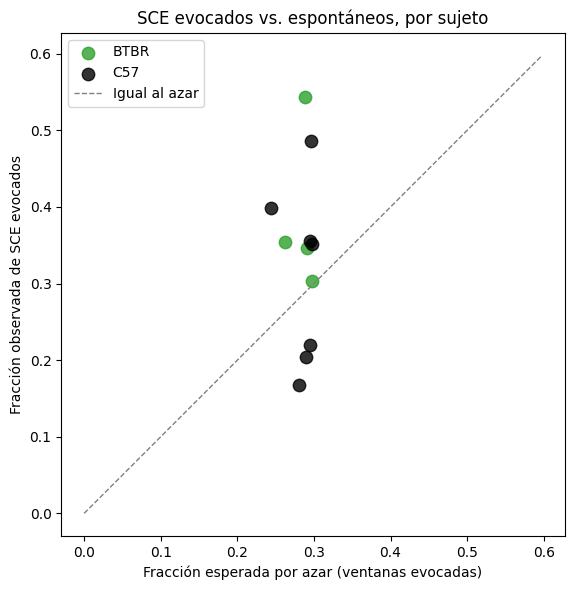

In [37]:
fig, ax = plt.subplots(figsize=(6, 6))

palette = {'BTBR': '#2ca02c', 'C57': '#000000'}

for geno in ['BTBR', 'C57']:
    subset = sce_evoked_df[sce_evoked_df['genotype'] == geno]
    ax.scatter(subset['frac_background'], subset['frac_observed'],
               label=geno, color=palette[geno], s=80, alpha=0.8)

lims = [0, max(sce_evoked_df['frac_background'].max(), sce_evoked_df['frac_observed'].max()) * 1.1]
ax.plot(lims, lims, ls='--', color='gray', lw=1, label='Igual al azar')

ax.set_xlabel('Fracción esperada por azar (ventanas evocadas)')
ax.set_ylabel('Fracción observada de SCE evocados')
ax.set_title('SCE evocados vs. espontáneos, por sujeto')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sce_evoked_vs_background.svg', format='svg', bbox_inches='tight')
plt.show()